# Import


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from kneed import KneeLocator

# Dataset


In [2]:
df = pd.read_csv("dvf_2025_mutations_propres.csv", dtype={"code_dept": str})

# Nettoyage


In [3]:
df = df[df["retenue_stats"]]
df = df[df["valeur_fonciere"] > 0].copy()

df["surface_bati"] = df[["surf_maison", "surf_appartement", "surf_local_pro"]].sum(axis=1)
df["terrain_total"] = df["terrain_total"].fillna(0)
df["nb_pieces"] = df["nb_pieces"].fillna(0)
df["code_dept"] = df["code_dept"].astype(str)

df["prix_m2"] = (
    df["prix_m2_fiable"]
    .fillna(df["prix_m2_terrain"])
    .fillna(df["prix_m2_pro"])
)

df = df.dropna(subset=["prix_m2"]).reset_index(drop=True)

print(f"Nombre total de biens : {len(df)}")
print(df["type_bien"].value_counts(dropna=False))

Nombre total de biens : 981878
type_bien
Maison                           364975
Appartement                      340965
Terrain agricole                 117091
Local pro                         47464
Terrain non bâti (sol/jardin)     41865
Terrain à bâtir                   37006
Forêt / bois                      22891
Appartement neuf (VEFA)            6576
Terrain autre                      3045
Name: count, dtype: int64


# Echantillon


In [4]:
df = df.sample(n=50000, random_state=42).reset_index(drop=True)
print(f"Nombre de biens apres echantillonnage : {len(df)}")

Nombre de biens apres echantillonnage : 50000


# Normalisation


In [5]:
# Par département
# df_encoded = pd.get_dummies(
#     df, columns=["code_departement", "type_bien"], prefix=["dept", "type"]
# )

# col_dimensions = nb_dimensions + [
#     c for c in df_encoded.columns if c.startswith("dept_") or c.startswith("type_")
# ]

col_dimensions = [
    "valeur_fonciere", "prix_m2", "surface_bati",
    "terrain_total", "nb_pieces",
]

X = np.column_stack([
    np.log1p(df[c].clip(lower=0).to_numpy(dtype=float)) for c in col_dimensions
])

X = StandardScaler().fit_transform(X)

# Paramètres


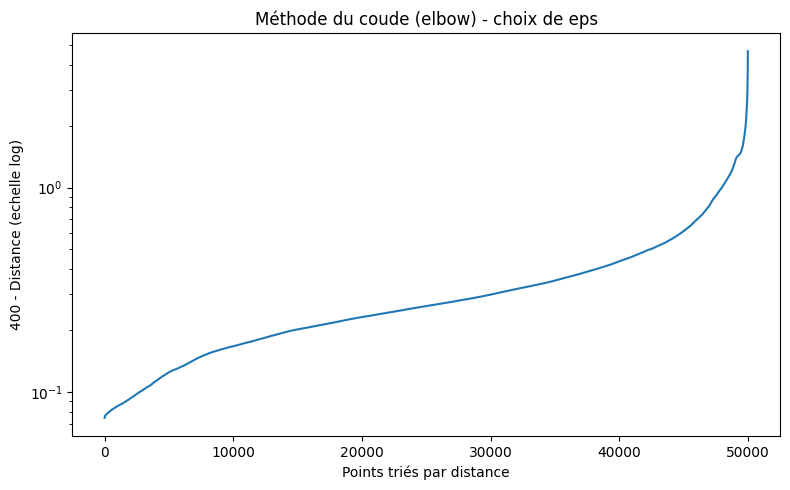

eps : 0.5017
min_samples : 400


In [6]:
eps = 0.5017
min_samples = 400

# min_samples = 2 * len(nb_dimensions)
neighbors_fit = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1).fit(X)
distances, _ = neighbors_fit.kneighbors(X)
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.yscale("log")
plt.xlabel("Points triés par distance")
plt.ylabel(f"{min_samples} - Distance (echelle log)")
plt.title("Méthode du coude (elbow) - choix de eps")
plt.tight_layout()
plt.show()

#################

# Utiliser cette partie si eps est trop grand
# cut = int(len(k_distances) * 0.99)
# k_distances_cut = k_distances[:cut]

# kneeLocator = KneeLocator(
#     range(len(k_distances_cut)), k_distances_cut,
#     curve="convex", direction="increasing"
# )
# eps = k_distances_cut[kneeLocator.knee]

############

# Mettre en commentqire cette partie si on utilise le bloc de code du haut
# kneeLocator = KneeLocator(
#     range(len(k_distances)), k_distances, curve="convex", direction="increasing"
# )

# eps = k_distances[kneeLocator.knee]

###############

print(f"eps : {eps:.4f}")
print(f"min_samples : {min_samples}")


# DBSCAN


In [7]:
db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

df["cluster_dbscan"] = labels

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = int((labels == -1).sum())

print(f"Nombre de clusters : {n_clusters_}")
print(f"Nombre de points de bruit (biens atypiques) : {n_noise_} "
      f"({100 * n_noise_ / len(labels):.1f}%)")

effectifs = df[df["cluster_dbscan"] != -1]["cluster_dbscan"].value_counts()
segments = effectifs[effectifs / len(df) * 100 >= 0.5].index


Nombre de clusters : 5
Nombre de points de bruit (biens atypiques) : 3439 (6.9%)


# Silhouette score


In [8]:
mask_valid = labels != -1
mask_seg = np.isin(labels, segments)

sc = metrics.silhouette_score(X[mask_valid], labels[mask_valid])

print("Silhouette Coefficient (hors bruit): %0.3f" % sc)

Silhouette Coefficient (hors bruit): 0.479


# Table des segments


In [9]:
def nommer(type_dom, surf, pieces, terrain):
    if type_dom.startswith(("Terrain", "For")):
        return f"Terrains & forets ({terrain:,.0f} m2)"
    if type_dom == "Local pro":
        return f"Locaux professionnels ({surf:.0f} m2)"
    if "VEFA" in type_dom:
        return "Appartements neufs (VEFA)"
    base = "Maisons" if type_dom == "Maison" else "Appartements"
    pieces_txt = "studios / T1" if pieces <= 1 else f"{pieces:.0f} pieces"
    surf_txt = f" ({surf:.0f} m2" if surf > 0 else " (surface non renseignee"
    terrain_txt = f", terrain {terrain:,.0f} m2)" if terrain > 300 else ")"
    return f"{base} {pieces_txt}{surf_txt}{terrain_txt}"


def nommer_court(type_dom, surf, pieces, terrain):
    if type_dom.startswith(("Terrain", "For")):
        return "Terrains"
    if type_dom == "Local pro":
        return "Locaux pro"
    if "VEFA" in type_dom:
        return "Appart. neuf"
    base = "Maison" if type_dom == "Maison" else "Appart."
    return f"{base} {'T1' if pieces <= 1 else f'{pieces:.0f}p'}"

table = (
    df[df["cluster_dbscan"].isin(segments)]
    .groupby("cluster_dbscan")
    .agg(
        effectif=("valeur_fonciere", "size"),
        valeur_med=("valeur_fonciere", "median"),
        prix_m2_med=("prix_m2", "median"),
        surf_med=("surface_bati", "median"),
        pieces_med=("nb_pieces", "median"),
        terrain_med=("terrain_total", "median"),
        volume=("valeur_fonciere", "sum"),
        type_dom=("type_bien", lambda s: s.mode().iat[0]),
        dept_top=("code_dept", lambda s: ", ".join(s.value_counts().head(3).index)),
    )
    .sort_values("effectif", ascending=False)
)

profils = list(zip(table["type_dom"], table["surf_med"],
                   table["pieces_med"], table["terrain_med"]))
table["segment"] = [nommer(*p) for p in profils]
table["court"] = [nommer_court(*p) for p in profils]
table["pct_marche"] = 100 * table["effectif"] / len(df)
table["pct_volume"] = 100 * table["volume"] / df["valeur_fonciere"].sum()
table["montant_median"] = table["valeur_med"]

presentation = table[[
    "segment", "effectif", "pct_marche", "pct_volume", "montant_median",
    "prix_m2_med", "surf_med", "terrain_med", "dept_top",
]]

pd.set_option("display.width", 250)
print(presentation.to_string(float_format=lambda v: f"{v:,.1f}"))

                                                 segment  effectif  pct_marche  pct_volume  montant_median  prix_m2_med  surf_med  terrain_med    dept_top
cluster_dbscan                                                                                                                                            
1               Maisons 4 pieces (93 m2, terrain 536 m2)     17175        34.4        37.2       210,000.0      2,215.9      93.0        536.0  59, 62, 33
0                          Appartements 3 pieces (62 m2)     15061        30.1        31.8       188,050.0      3,230.8      62.0          0.0  75, 06, 13
2                           Terrains & forets (2,550 m2)     10602        21.2         4.6        18,000.0          3.5       0.0      2,550.0  85, 44, 56
3                      Appartements studios / T1 (26 m2)      2967         5.9         3.2       108,885.0      4,166.7      26.0          0.0  75, 06, 34
4                          Locaux professionnels (56 m2)       756    

# Visualisation : familles et segments


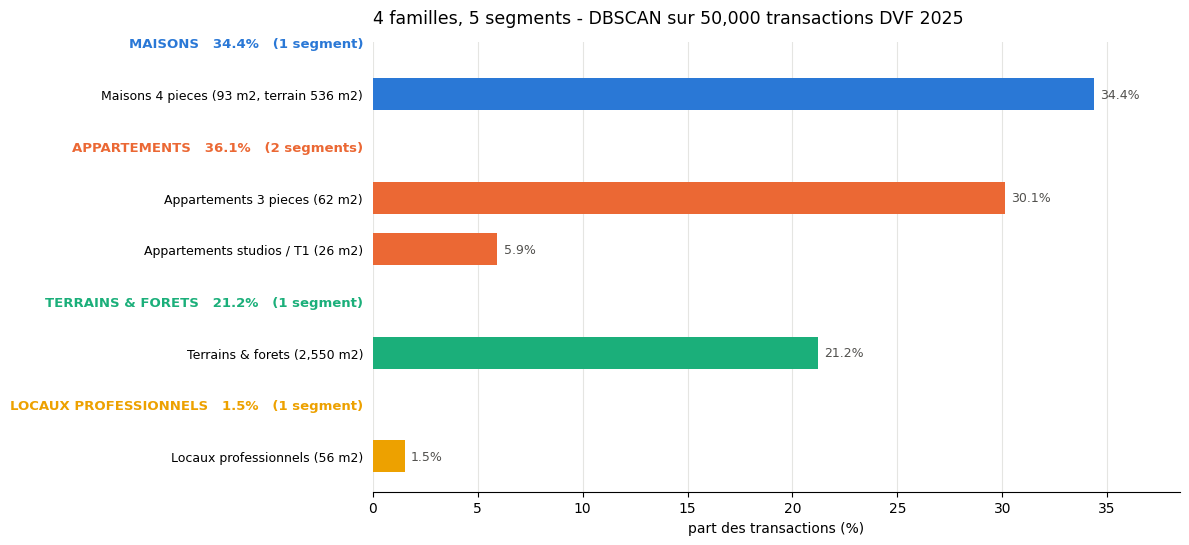

In [10]:
ORDRE_FAMILLES = ["Maisons", "Appartements", "Terrains & forets", "Locaux professionnels"]


def famille_de(type_dom):
    if type_dom.startswith(("Terrain", "For")):
        return "Terrains & forets"
    if type_dom == "Local pro":
        return "Locaux professionnels"
    return "Maisons" if type_dom == "Maison" else "Appartements"


table["famille"] = table["type_dom"].map(famille_de)
hierarchie = table.sort_values(
    ["famille", "pct_marche"],
    key=lambda s: (s.map({f: i for i, f in enumerate(ORDRE_FAMILLES)})
                   if s.name == "famille" else -s),
)

COULEUR_FAMILLE = {
    "Maisons": "#2a78d6",
    "Appartements": "#eb6834",
    "Terrains & forets": "#1baf7a",
    "Locaux professionnels": "#eda100",
}

rangs = []
for fam in ORDRE_FAMILLES:
    bloc = hierarchie[hierarchie["famille"] == fam]
    if bloc.empty:
        continue
    rangs.append({"label": f"{fam.upper()}   {bloc['pct_marche'].sum():.1f}%"
                           f"   ({len(bloc)} segment{'s' if len(bloc) > 1 else ''})",
                  "valeur": None, "couleur": COULEUR_FAMILLE[fam], "entete": True})
    for _, r in bloc.iterrows():
        rangs.append({"label": f"      {r['segment']}", "valeur": r["pct_marche"],
                      "couleur": COULEUR_FAMILLE[fam], "entete": False})

y = np.arange(len(rangs))
barres = [(i, r) for i, r in enumerate(rangs) if not r["entete"]]

fig, ax = plt.subplots(figsize=(12, 0.44 * len(rangs) + 1.6))
ax.barh([i for i, _ in barres], [r["valeur"] for _, r in barres],
        color=[r["couleur"] for _, r in barres], height=0.62)
for i, r in barres:
    ax.text(r["valeur"] + 0.3, i, f"{r['valeur']:.1f}%", va="center",
            fontsize=9, color="#52514e")

ax.set_yticks(y, [r["label"] for r in rangs], fontsize=9)
for etiquette, r in zip(ax.get_yticklabels(), rangs):
    if r["entete"]:
        etiquette.set_fontweight("bold")
        etiquette.set_color(r["couleur"])
        etiquette.set_fontsize(9.5)
ax.invert_yaxis()

ax.set_xlabel("part des transactions (%)")
ax.set_title(f"{len(ORDRE_FAMILLES)} familles, {len(table)} segments - "
             f"DBSCAN sur {len(df):,} transactions DVF 2025",
             fontsize=12.5, loc="left", pad=14)
ax.set_xlim(0, max(r["valeur"] for _, r in barres) * 1.12)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis="x", color="#e5e5e2", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Empreinte de chaque segment


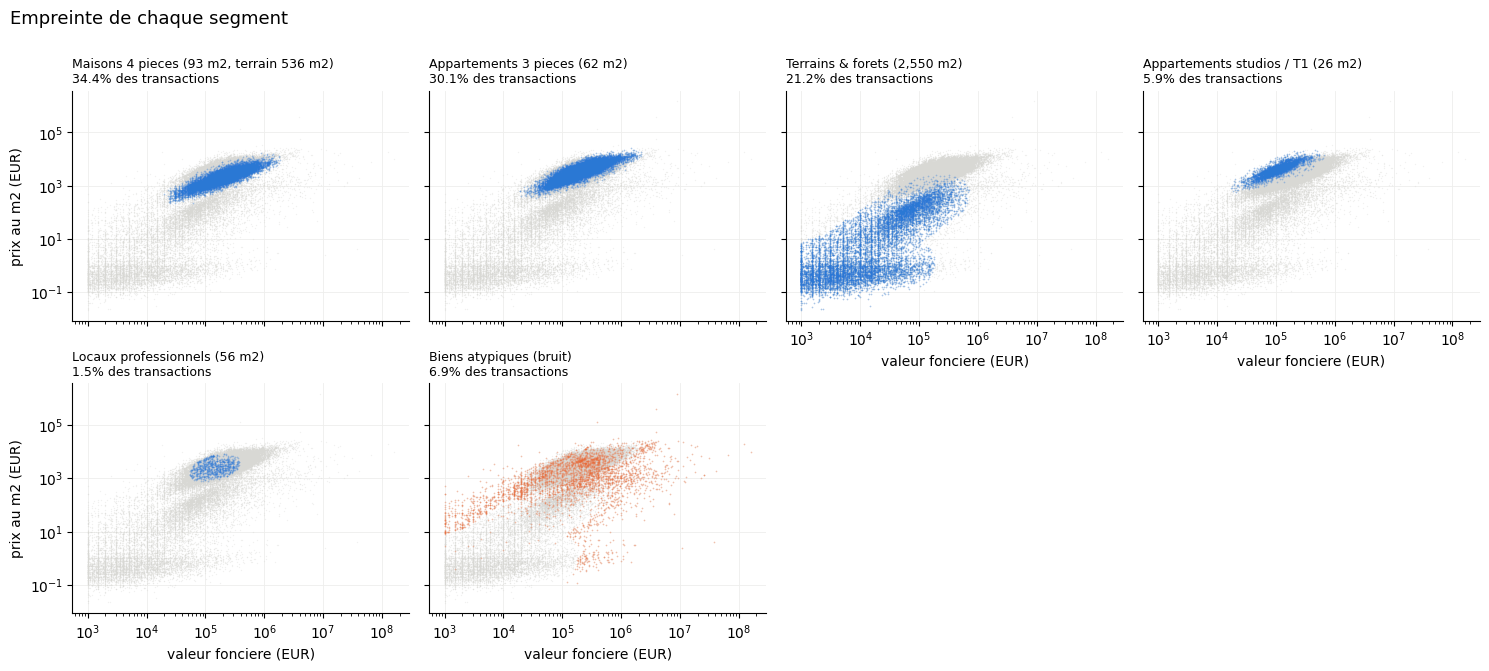

In [11]:
rng_plot = np.random.default_rng(0)
fond = df.iloc[rng_plot.choice(len(df), min(60_000, len(df)), replace=False)]

ordre_seg = list(table.index) + [-1]
noms_seg = list(table["segment"]) + ["Biens atypiques (bruit)"]

ncol = 4
nrow = int(np.ceil(len(ordre_seg) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.4 * nrow),
                         sharex=True, sharey=True)

for ax, c, nom in zip(axes.ravel(), ordre_seg, noms_seg):
    ax.scatter(fond["valeur_fonciere"], fond["prix_m2"],
               s=1, color="#d8d8d4", alpha=0.35, linewidths=0, rasterized=True)
    sub = df[df["cluster_dbscan"] == c]
    if len(sub) > 15_000:
        sub = sub.iloc[rng_plot.choice(len(sub), 15_000, replace=False)]
    couleur = "#eb6834" if c == -1 else "#2a78d6"
    ax.scatter(sub["valeur_fonciere"], sub["prix_m2"],
               s=1.5, color=couleur, alpha=0.35, linewidths=0, rasterized=True)
    pct = 100 * (df["cluster_dbscan"] == c).sum() / len(df)
    ax.set_title(f"{nom}\n{pct:.1f}% des transactions", fontsize=9, loc="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(color="#eeeeec", lw=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

for ax in axes.ravel()[len(ordre_seg):]:
    ax.set_visible(False)

for col in range(ncol):
    visibles = [r for r in range(nrow) if axes[r, col].get_visible()]
    if not visibles:
        continue
    bas = axes[visibles[-1], col]
    bas.tick_params(labelbottom=True)
    bas.set_xlabel("valeur fonciere (EUR)")
for ax in axes[:, 0]:
    ax.set_ylabel("prix au m2 (EUR)")

fig.suptitle(f"Empreinte de chaque segment",
             fontsize=13, x=0.01, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Gamme de prix et ticket moyen


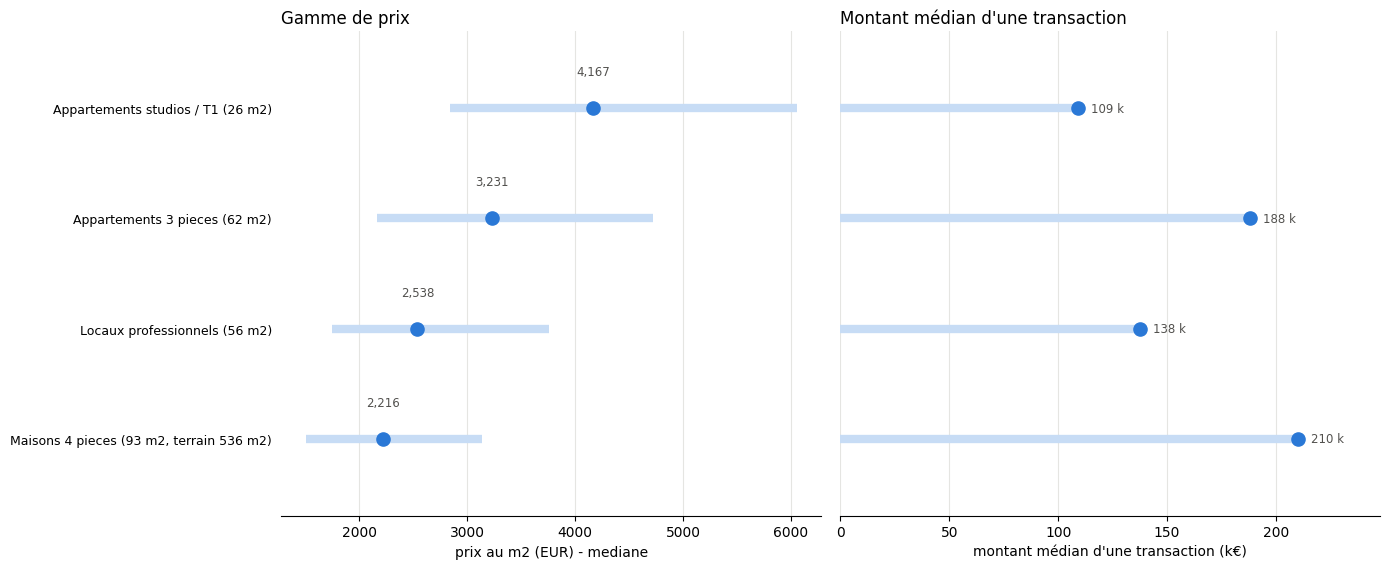

In [12]:
ordre = table.sort_values("prix_m2_med")
bati = ordre[ordre["surf_med"] > 0]          # le prix au m2 n'a pas de sens pour les terrains
y = np.arange(len(bati))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.8), sharey=True)

# prix au m2
q1 = [df[df["cluster_dbscan"] == c]["prix_m2"].quantile(.25) for c in bati.index]
q3 = [df[df["cluster_dbscan"] == c]["prix_m2"].quantile(.75) for c in bati.index]
ax1.hlines(y, q1, q3, color="#c7dcf5", lw=6)
ax1.scatter(bati["prix_m2_med"], y, s=90, color="#2a78d6", zorder=3)
for i, v in enumerate(bati["prix_m2_med"]):
    ax1.text(v, y[i] + 0.3, f"{v:,.0f}", ha="center", fontsize=8.5, color="#52514e")
ax1.set_yticks(y, bati["segment"], fontsize=9)
ax1.set_xlabel("prix au m2 (EUR) - mediane")
ax1.set_title("Gamme de prix", fontsize=12, loc="left")

# montant median d'une transaction
ax2.hlines(y, 0, bati["montant_median"] / 1000, color="#c7dcf5", lw=6)
ax2.scatter(bati["montant_median"] / 1000, y, s=90, color="#2a78d6", zorder=3)
for i, v in enumerate(bati["montant_median"] / 1000):
    ax2.text(v + 6, y[i], f"{v:,.0f} k", va="center", fontsize=8.5, color="#52514e")
ax2.set_xlabel("montant médian d'une transaction (k€)")
ax2.set_title("Montant médian d'une transaction", fontsize=12, loc="left")
ax2.set_xlim(0, bati["montant_median"].max() / 1000 * 1.18)

for ax in (ax1, ax2):
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis="x", color="#e5e5e2", lw=0.8)
    ax.set_axisbelow(True)
    ax.set_ylim(-0.7, len(bati) - 0.3)

plt.tight_layout()
plt.show()

# Biens atypiques


In [13]:
atypiques = df[df["cluster_dbscan"] == -1]
part_vol = 100 * atypiques["valeur_fonciere"].sum() / df["valeur_fonciere"].sum()

print(f"Biens atypiques : {len(atypiques):,} ({100 * len(atypiques) / len(df):.1f}% des transactions)")
print(f"Volume represente : {atypiques['valeur_fonciere'].sum() / 1e9:.1f} Md EUR "
      f"({part_vol:.1f}% du volume total)")
print(f"\nValeur mediane : {atypiques['valeur_fonciere'].median():,.0f} EUR "
      f"(marche : {df['valeur_fonciere'].median():,.0f} EUR)")
print(f"Prix/m2 median : {atypiques['prix_m2'].median():,.0f} EUR "
      f"(marche : {df['prix_m2'].median():,.0f} EUR)")


def sur_representation(colonne, titre, seuil_part=1.0):
    """Compare la composition des atypiques a celle du marche."""
    chez_atypiques = atypiques[colonne].value_counts(normalize=True) * 100
    sur_le_marche = df[colonne].value_counts(normalize=True) * 100
    rapport = (chez_atypiques / sur_le_marche).dropna().sort_values(ascending=False)
    rapport = rapport[chez_atypiques.reindex(rapport.index) >= seuil_part]

    print(f"\n{titre}")
    print(f"  {'':30s} {'atypiques':>10s} {'marche':>9s} {'rapport':>9s}")
    for k in rapport.head(5).index:
        print(f"  {str(k):30s} {chez_atypiques[k]:9.1f}% {sur_le_marche[k]:8.1f}% "
              f"{rapport[k]:8.1f}x")


sur_representation("type_bien", "Types de biens sur-representes :")
sur_representation("code_dept", "Departements sur-representes :", seuil_part=0.5)

Biens atypiques : 3,439 (6.9% des transactions)
Volume represente : 2.6 Md EUR (22.1% du volume total)

Valeur mediane : 200,000 EUR (marche : 155,000 EUR)
Prix/m2 median : 939 EUR (marche : 2,099 EUR)

Types de biens sur-representes :
                                  atypiques    marche   rapport
  Appartement neuf (VEFA)              9.6%      0.7%     14.5x
  Local pro                           49.8%      4.9%     10.1x
  Terrain non bâti (sol/jardin)       10.2%      4.3%      2.4x
  Terrain à bâtir                      2.8%      3.8%      0.7x
  Terrain agricole                     8.1%     11.9%      0.7x

Departements sur-representes :
                                  atypiques    marche   rapport
  971                                  0.8%      0.3%      3.0x
  2A                                   0.6%      0.3%      2.3x
  46                                   0.6%      0.3%      1.6x
  32                                   0.5%      0.3%      1.6x
  73                        